In [1]:
import numpy as np
import matplotlib.pyplot as plt

Simulated Annealing

/tmp/ipykernel_22603/3972180714.py:34: RuntimeWarning: divide by zero encountered in scalar divide
  T_atual = T0 / np.log(1 + i)


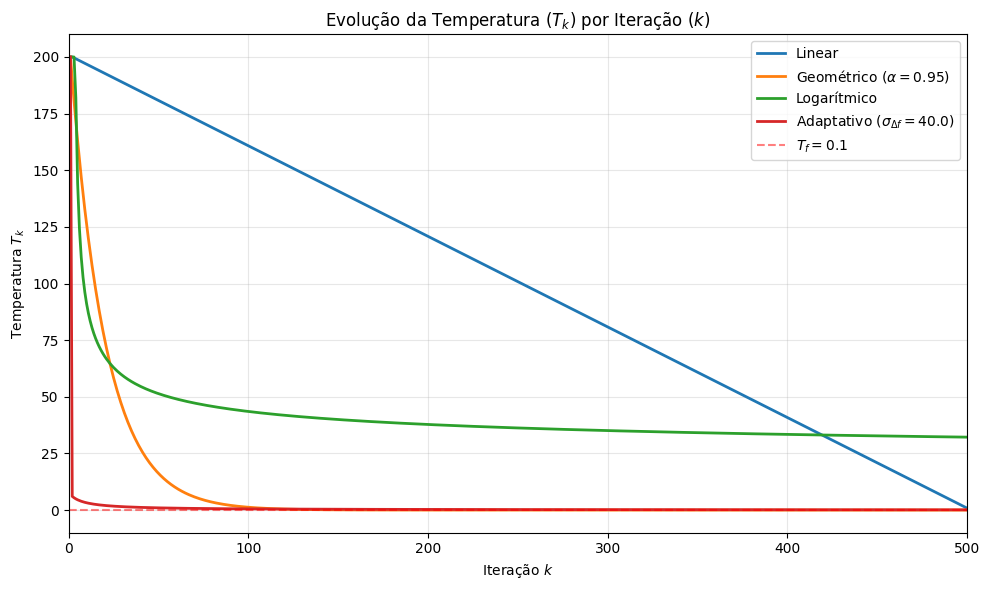

In [10]:
# Parâmetros fornecidos
T0 = 200.0
Tf = 0.1
K = 500
alpha = 0.95
delta_df = 40.0

# Array de iterações (iniciando em 1 para evitar divisão por zero no logarítmico)
k_vals = np.arange(1, K+1)

# 1. Esquema Linear
delta_T = (T0 - Tf) / K
T_linear = np.zeros(K)
T_atual = T0
for i in range(K):
    T_linear[i] = T_atual
    T_atual = T0 - i * delta_T

# 2. Esquema Geométrico
T_geom = np.zeros(K)
T_atual = T0
for i in range(K):
    T_geom[i] = T_atual
    T_atual = T_atual * alpha

# 3. Esquema Logarítmico
T_log = np.zeros(K)
T_atual = T0
for i in range(K):
  if T_atual <= 200:
    T_log[i] = T_atual
  else:
    T_log[i] = 200
  T_atual = T0 / np.log(1 + i)

# 4. Esquema Adaptativo
T_adapt = np.zeros(K)
T_atual = T0
for i in range(K):
    T_adapt[i] = T_atual
    T_atual = T_atual * np.exp(-0.7 * (T_atual / delta_df))

# Plotagem
plt.figure(figsize=(10, 6))
plt.plot(k_vals, T_linear, label='Linear', linewidth=2)
plt.plot(k_vals, T_geom, label='Geométrico ($\\alpha=0.95$)', linewidth=2)
plt.plot(k_vals, T_log, label='Logarítmico', linewidth=2)
plt.plot(k_vals, T_adapt, label=f'Adaptativo ($\\sigma_{{\\Delta f}}={delta_df}$)', linewidth=2)

plt.axhline(y=Tf, color='r', linestyle='--', alpha=0.5, label=f'$T_f={Tf}$')
plt.ylim(-10, 210)
plt.xlim(0, K)
plt.title('Evolução da Temperatura ($T_k$) por Iteração ($k$)')
plt.xlabel('Iteração $k$')
plt.ylabel('Temperatura $T_k$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()